## 3.4. Các phân phối thông dụng

Có rất nhiều loại phân phối khác nhau tuy nhiên trong thực tế sử dụng, một số quy luật phổ biến là: binomial distribution đối với biến rời rạc, normal và T-distribution với biến liên tục

### Binomial distribution
[Binomial distribution](https://en.wikipedia.org/wiki/Binomial_distribution) là một hàm phân phối rời rạc, được định nghĩa là xác suất thành công $k$ $(k\in\mathbb{N})$ lần trong $n$ $(n\in\mathbb{N})$ lần thử. Mỗi lần thử chỉ có 2 kết quả: thành công có xác suất là $p$ hoặc thất bại có xác suất là $1-p$. Hàm PMF của phân phối binomial distribution có dạng:

$$f(k;n) = \frac{n!}{k!(n-k)!} p^k (1-p)^{n-k}$$

Nếu biến $\mathbf{x}$ tuân theo quy luật phân phối binomial: $\mathbf{x}\sim \mbox{Bin}(n,p)$ thì $\mathbf{x}$ có trung bình là $np$ và phương sai $np(1-p)$

♈ **Coding Session 8**

Có 1 đồng xu đồng chất (mỗi lần tung đồng xu sẽ trả ra 2 kết quả sấp, ngửa và mỗi mặt có xác suất xuất hiện là 0.5). Tung đồng xu 6 lần, phân phối binomial có thể được sử dụng để tính:

- Xác suất có 4 mặt ngửa
- Xác suất có nhiều nhất 3 mặt ngửa
- Xác suất có nhiều hơn 3 mặt ngửa
- Trung bình số lần xuất hiện mặt ngửa

In [ ]:
from scipy import stats
stats.binom(n=6, p=0.5).pmf(4)

0.234375

In [ ]:
stats.binom(n=6, p=0.5).cdf(3)

0.65625

In [ ]:
stats.binom(n=6, p=0.5).sf(3)

0.34375

In [ ]:
stats.binom(n=6, p=0.5).mean()

3.0

♈ **Case Study 9**

DASCA là 1 chứng chỉ quốc tế cho senior DA, biết tỷ lệ pass chứng chỉ này là 60%. Nếu công ty A cử 10 người đi thi thì tính:
- Xác suất để có 7 người pass
- Xác suất để có 6 người pass trở lên

In [ ]:
stats.binom(n=10, p=0.6).pmf(7)

0.21499084799999976

In [ ]:
stats.binom(n=10, p=0.6).sf(6)

0.3822806015999999

In [ ]:
dist.sf(6) + dist.pmf(6)

0.6331032575999997

In [ ]:
dist = stats.binom(n=10, p=0.6)

### Normal distribution
[Normal distribution](https://en.wikipedia.org/wiki/Normal_distribution) (Phân phối chuẩn hay phân phối Gaussian) là một phân phối liên tục và chiếm vai trò quan trọng trong thống kê. Vì rất nhiều biến ngẫu nhiên liên tục trong thực tế đều tuân theo phân phối chuẩn như: cân nặng, điểm IQ, huyết áp, size giày,... Phân phối chuẩn còn là nền tảng cho rất nhiều phân phối và định lí, thuật toán ví dụ như định lí giới hạn trung tâm. Hàm PDF của phân phối chuẩn có dạng:

$$f(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}}\cdot\exp{\left(-\frac{1}{2}{\frac{(x-\mu)^2}{\sigma^2}}\right)}$$

Nếu biến ngẫu nhiên $\mathbf{x}$ tuân theo phân phối chuẩn: $\mathbf{x}\sim \mathcal{N}(\mu,\sigma)$, thì $\mathbf{x}$ có trung bình là $\mu$ và phương sai là $\sigma^2$. Trong trường hợp $\mathbf{x}\sim \mathcal{N}(0,1)$, thì biến $\mathbf{x}$ tuân theo phân phối chuẩn tắc

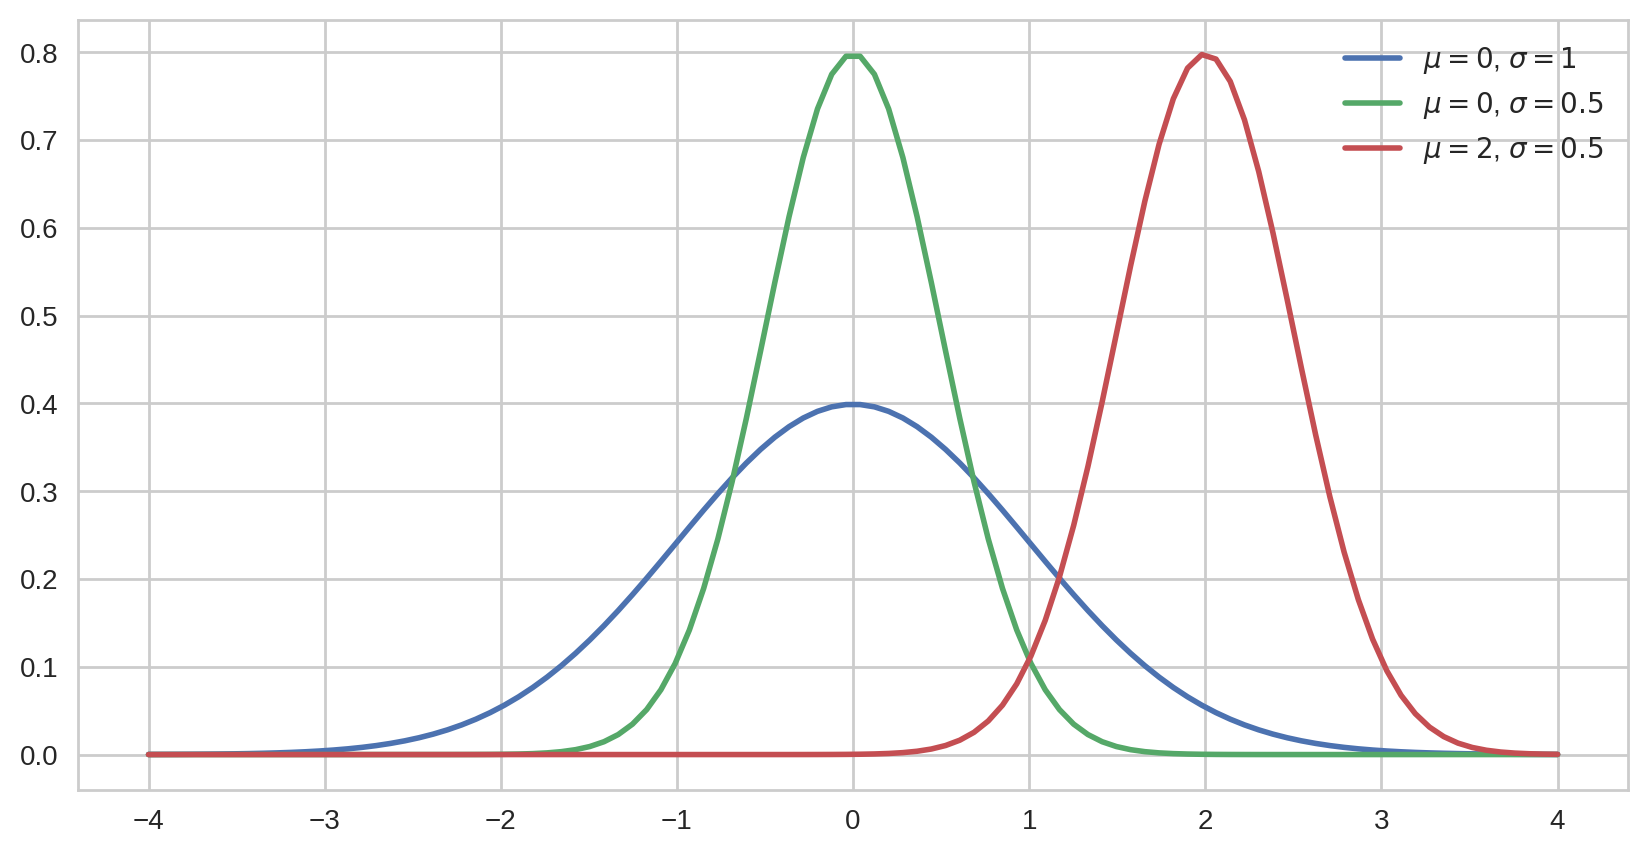

In [ ]:
#@title
data = [(0, 1), (0, 0.5), (2, 0.5)]
fig, ax = plt.subplots(figsize=(10,5))
for mu, sigma in data:
    x = np.linspace(-4, 4, 100)
    y = stats.norm(mu, sigma).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$\mu={mu}$, $\sigma={sigma}$' for mu, sigma in data])
plt.show()

♈ **Coding Session 10**

Trong hệ thống tỷ giá hối đoái thả nổi, sự biến động của tỷ giá hối đoái chịu sự tác động của rất nhiều nhân tố và có thể xem như biến ngẫu nhiên phấn phối chuẩn, giả sử ở một giai đoạn nào đó tỷ giá của USD với VND có trung bình là 23000đ và độ lệch chuẩn là 800đ. Tìm xác suất để trong một ngày nào đó:
- Tỷ giá sẽ cao hơn 24000đ
- Tỷ giá sẽ thấp hơn 22800đ
- Nằm trong khoảng 22800đ đến 24000đ

In [ ]:
stats.norm(loc=23000, scale=800).sf(24000)

0.10564977366685535

In [ ]:
stats.norm(loc=23000, scale=800).cdf(22800)

0.4012936743170763

In [ ]:
min = stats.norm(loc=23000, scale=800).cdf(22800)
max = stats.norm(loc=23000, scale=800).cdf(24000)
max-min

0.49305655201606835

♈ **Case Study 11**

Chiều cao nam giới khi trưởng thành ở một vùng dân cư là biến ngẫu nhiên phân phối chuẩn với $\mu=160$ cm và $\sigma=6$ cm . Một thanh niên bị coi là thấp nếu có chiều cao nhỏ hơn 155 cm. Tìm tỷ lệ thanh niên thấp ở vùng đó


In [ ]:
p_short = stats.norm(loc=160, scale=6).cdf(155)
p_short

0.20232838096364308

### T-distribution

T-distribution có hình dạng gần giống normal distribution nhưng có phần đuôi cao hơn (fat tails). Nói cách khác dữ liệu có phân phối T thường xa trung bình hơn dữ liệu có phân phối chuẩn. Khi cỡ mẫu trên 30 thì có thể nói phân phối T rất gần với phân phối chuẩn

Phân phối T được sử dụng để Kiểm định giả thuyết khi chưa biết phương sai của tổng thể hoặc ước lượng khi cỡ mẫu dưới 30.

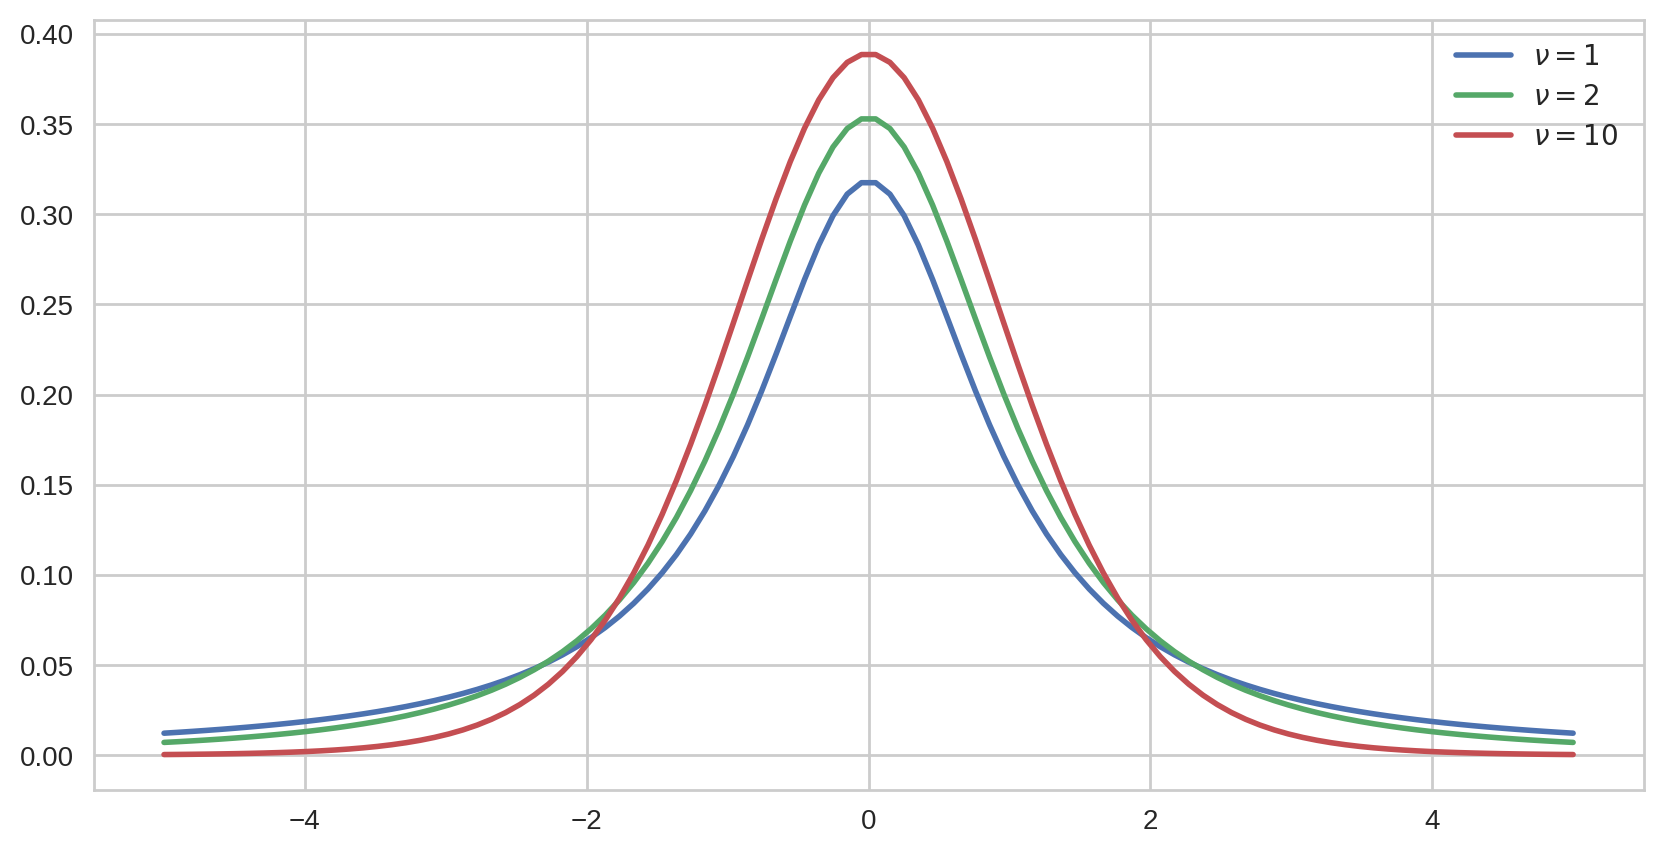

In [ ]:
#@title
data = [1, 2, 10]
fig, ax = plt.subplots(figsize=(10,5))
for nu in data:
    x = np.linspace(-5, 5, 100)
    y = stats.t(nu).pdf(x)
    ax.plot(x, y, linewidth=2)
ax.legend([fr'$\nu={nu}$' for nu in data])
plt.show()

## 3.5. Định lý giới hạn trung tâm

Định lý giới hạn trung tâm (Central Limit Theorem) là một định lý quan trọng trong thống kê và được ứng dụng trong nhiều nghiên cứu cũng như thực tiễn cuộc sống. CLT cho rằng khi bạn lấy 1 mẫu (sample) ngẫu nhiên nhiều lần từ một tổng thể thì kể cả khi tổng thể không phân phối chuẩn, trung bình mẫu (sample means) vẫn tuân theo phân phối chuẩn. Một số ứng dụng của CLT bao gồm:
- Ứng dụng trong ước lượng và kiểm định thống kê khi tổng thể không phân phối chuẩn
- Tiết kiệm thời gian và chi phí đối với các cuộc khảo sát vì chỉ cần thu thập dữ liệu mẫu mà không cần thu thập dữ liệu tổng thể.


♈ **Concept Explained 12**

[Animation](https://seeing-theory.brown.edu/probability-distributions/index.html#section3) mô tả nội dung của Định lý Giới hạn Trung tâm.

♈ **Coding Session 4**: Steve muốn mua cuốn sách "The Art of Probability" trên Amazon và tham khảo được 2 nơi bán như sau:
- Shop GreenEggs có $n_1=50$ ratings với tỷ lệ đánh giá tích cực là $\hat p_1=96\%$
- Shop HammingTime có $n_2=200$ ratings với tỷ lệ đánh giá tích cực là $\hat p_2=93\%$

Với mức sai số cho phép $\alpha=10\%$, hãy giúp Steve đưa ra quyết định nên chọn mua sách ở shop nào.

In [ ]:
import numpy as np
from scipy import stats

n1, n2 = 50, 200
p1 = 0.96
p2 = 0.93
alpha = 0.1
gamma = 1 - alpha

crit = stats.norm().ppf(alpha/2)
eps = -crit * np.sqrt(p1 *(1-p1)/n1 + p2*(1-p2)/n2)
lower = p1 - p2 - eps
upper = p1 - p2 + eps

print(f'Với độ tin cậy {gamma:.0%}, chênh lệch tỷ lệ review tích cực nằm trong khoảng ({lower:.2%}, {upper:.2%})')